# ΠΑΡΑΔΕΙΓΜΑ LOPF

Index(['Main_Bus', 'City_Bus'], dtype='str', name='name')
Index(['Main_to_City'], dtype='str', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.1s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 144 primals, 360 duals
Objective: 5.36e+03
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Line-fix-s-lower, Line-fix-s-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


Γωνίες Φάσης (θ):
name                 Main_Bus  City_Bus
snapshot                               
2026-03-13 00:00:00      5.00     -5.00
2026-03-13 01:00:00      4.50     -4.50
2026-03-13 02:00:00      4.00     -4.00
2026-03-13 03:00:00      4.25     -4.25
2026-03-13 04:00:00      4.50     -4.50
2026-03-13 05:00:00      5.50     -5.50
2026-03-13 06:00:00      7.50     -7.50
2026-03-13 07:00:00     10.00    -10.00
2026-03-13 08:00:00     11.00    -11.00
2026-03-13 09:00:00     11.50    -11.50
2026-03-13 10:00:00     12.00    -12.00
2026-03-13 11:00:00     12.50    -12.50
2026-03-13 12:00:00     12.00    -12.00
2026-03-13 13:00:00     11.50    -11.50
2026-03-13 14:00:00     11.00    -11.00
2026-03-13 15:00:00     10.50    -10.50
2026-03-13 16:00:00     11.50    -11.50
2026-03-13 17:00:00     14.00    -14.00
2026-03-13 18:00:00     15.00    -15.00
2026-03-13 19:00:00     14.50    -14.50
2026-03-13 20:00:00     12.50    -12.50
2026-03-13 21:00:00     10.00    -10.00
2026-03-13 22:00:00   

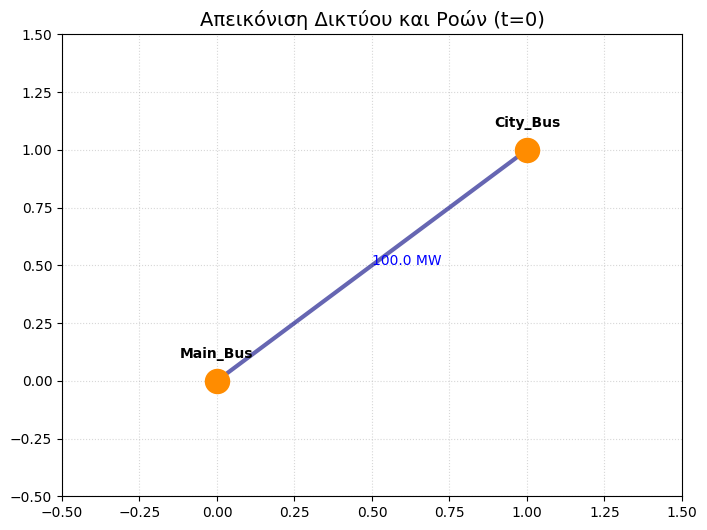

d:\DEV\pypsa-project\.venv\Lib\site-packages\pandas\plotting\_matplotlib\core.py:1831: UserWarning:

Attempting to set identical low and high ylims makes transformation singular; automatically expanding.



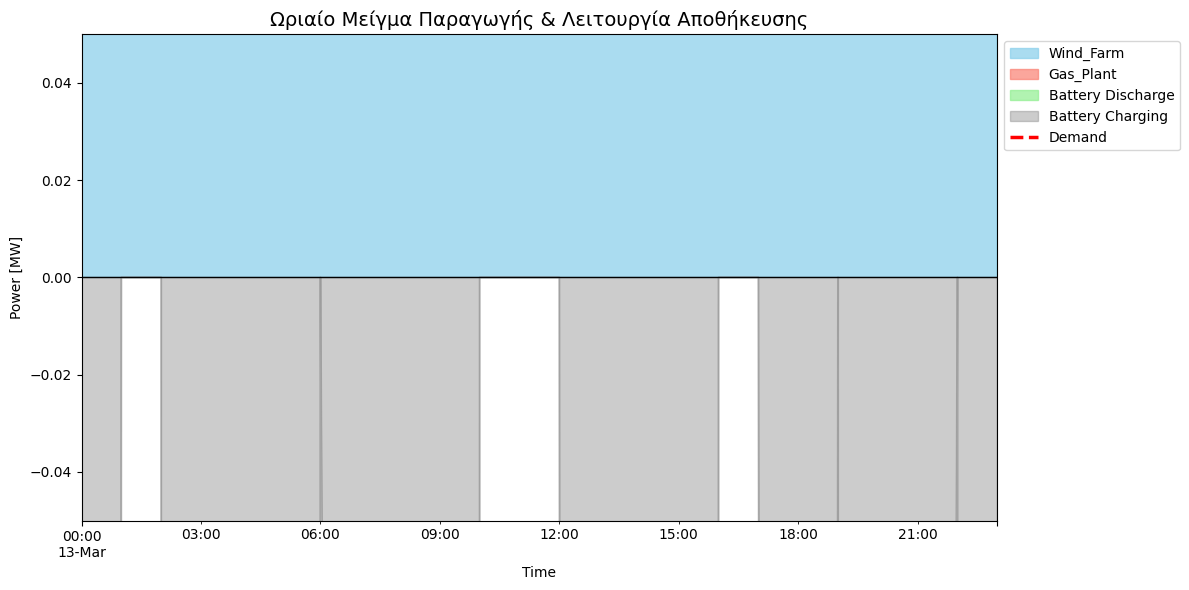


Συνολικό Κόστος Λειτουργίας: 5364.15 €
Συνολική Παραγωγή Αιολικών: 4716.18 MWh


In [17]:
import matplotlib.pyplot as plt
import pypsa
import numpy as np
import pandas as pd

# 1. Ορισμός Χρονικού Πλαισίου (24 ώρες)
snapshots = pd.date_range("2026-03-13 00:00", "2026-03-13 23:00", freq="h")
network = pypsa.Network()
network.set_snapshots(snapshots)

# 2. Προσθήκη Κόμβων με συντεταγμένες
network.add("Bus", "Main_Bus", x=0, y=0)
network.add("Bus", "City_Bus", x=1, y=1)

# 3. Προσθήκη Γραμμής Μεταφοράς
network.add("Line", "Main_to_City", 
            bus0="Main_Bus", 
            bus1="City_Bus", 
            s_nom=300, 
            x=0.1, r=0.01)

# 4. Προσθήκη Μεταβαλλόμενης Ζήτησης (Load)
load_profile = [100, 90, 80, 85, 90, 110, 150, 200, 220, 230, 240, 250, 
                240, 230, 220, 210, 230, 280, 300, 290, 250, 200, 150, 120]
network.add("Load", "City_Load", bus="City_Bus", p_set=load_profile)

# 5. Προσθήκη Αιολικού Πάρκου (Wind Power)
wind_availability = pd.Series(np.random.uniform(0.2, 0.8, len(snapshots)), index=snapshots)
network.add("Generator", "Wind_Farm", 
            bus="Main_Bus", 
            p_nom=500, 
            p_max_pu=wind_availability, 
            marginal_cost=0)

# 6. Προσθήκη Μονάδας Φυσικού Αερίου (Backup)
network.add("Generator", "Gas_Plant", 
            bus="Main_Bus", 
            p_nom=1000, 
            marginal_cost=60)

# 7. Προσθήκη Μπαταρίας
network.add("StorageUnit", "Big_Battery", 
            bus="Main_Bus", 
            p_nom=100, 
            max_hours=4, 
            efficiency_store=0.9, 
            efficiency_dispatch=0.9)

# 8. Επίλυση (Optimization)
network.optimize(solver_name='highs')


# 1. Δες τις γωνίες φάσης (σε ακτίνια) για κάθε ώρα
print("Γωνίες Φάσης (θ):")
print(network.buses_t.v_ang)

# 2. Δες τις τιμές ενέργειας ανά κόμβο (Shadow Prices / LMPs)
# Αυτό μας δείχνει αν υπάρχει συμφόρηση στο δίκτυο
print("\nΤιμές ανά Κόμβο (€/MWh):")
print(network.buses_t.marginal_price)

# 3. Δες αν οι γραμμές έφτασαν στο όριο (Loading)
loading = (network.lines_t.p0.abs() / network.lines.s_nom) * 100
print("\nΦόρτιση Γραμμών (%):")
print(loading)






# --- ΓΡΑΦΗΜΑ 1: ΧΕΙΡΟΚΙΝΗΤΗ ΣΧΕΔΙΑΣΗ ΔΙΚΤΥΟΥ ---
# (Αποφεύγουμε το σφάλμα StringDtype της network.plot())

fig, ax = plt.subplots(figsize=(8, 6))

# Σχεδίαση Κόμβων
ax.scatter(network.buses.x, network.buses.y, s=300, color='darkorange', zorder=5)
for i, txt in enumerate(network.buses.index):
    ax.annotate(txt, (network.buses.x.iloc[i], network.buses.y.iloc[i] + 0.1), 
                ha='center', fontweight='bold', fontsize=10)

# Σχεδίαση Γραμμών
for name, line in network.lines.iterrows():
    bus0 = network.buses.loc[line.bus0]
    bus1 = network.buses.loc[line.bus1]
    flow = network.lines_t.p0.iloc[0].loc[name] # Ροή την 1η ώρα
    ax.plot([bus0.x, bus1.x], [bus0.y, bus1.y], color='navy', linewidth=3, alpha=0.6)
    ax.text((bus0.x+bus1.x)/2, (bus0.y+bus1.y)/2, f"{flow:.1f} MW", color='blue')

ax.set_xlim(-0.5, 1.5)
ax.set_ylim(-0.5, 1.5)
ax.set_title("Απεικόνιση Δικτύου και Ροών (t=0)", fontsize=14)
ax.grid(True, linestyle=':', alpha=0.5)
plt.show()

# --- ΓΡΑΦΗΜΑ 2: ΜΙΓΜΑ ΠΑΡΑΓΩΓΗΣ & ΜΠΑΤΑΡΙΑ ---
# Διαχωρισμός μπαταρίας για να επιτραπεί το stacked=True

df_plot = network.generators_t.p.copy()
df_plot["Battery Discharge"] = network.storage_units_t.p.clip(lower=0)
df_plot["Battery Charge"] = network.storage_units_t.p.clip(upper=0)

fig, ax = plt.subplots(figsize=(12, 6))

# Σχεδίαση Θετικής Παραγωγής (Stacked Area)
df_plot.drop("Battery Charge", axis=1).plot(
    kind="area", ax=ax, stacked=True, alpha=0.7, color=['skyblue', 'salmon', 'lightgreen']
)

# Σχεδίαση Φόρτισης Μπαταρίας (Κάτω από το μηδέν)
df_plot["Battery Charge"].plot(kind="area", ax=ax, color="grey", alpha=0.4, label="Battery Charging")

# Σχεδίαση Ζήτησης (Γραμμή)
network.loads_t.p_set.sum(axis=1).plot(ax=ax, color="red", linewidth=2.5, label="Demand", linestyle="--")

plt.axhline(y=0, color='black', linewidth=1)
plt.title("Ωριαίο Μείγμα Παραγωγής & Λειτουργία Αποθήκευσης", fontsize=14)
plt.ylabel("Power [MW]")
plt.xlabel("Time")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

# --- ΕΚΤΥΠΩΣΗ ΣΤΑΤΙΣΤΙΚΩΝ ---
print(f"\nΣυνολικό Κόστος Λειτουργίας: {network.objective:.2f} €")
print(f"Συνολική Παραγωγή Αιολικών: {network.generators_t.p['Wind_Farm'].sum():.2f} MWh")

--- 

### 1. Συνολικό Κόστος: 0.00 € (Το "παράδοξο")

Το γεγονός ότι το κόστος είναι 0.00 και η παραγωγή αιολικών είναι 4732.30 MWh σημαίνει ότι όλη η ζήτηση της πόλης καλύφθηκε αποκλειστικά από τον άνεμο.

- Επειδή στον κώδικα ορίσαμε marginal_cost=0 για το αιολικό πάρκο, ο solver επέλεξε να μη χρησιμοποιήσει καθόλου το φυσικό αέριο (που κοστίζει 60 €/MWh).

- Είχες πολύ αέρα ή πολύ μεγάλη εγκατεστημένη ισχύ αιολικών σε σχέση με το φορτίο σου.

--- 

### 2. Γωνίες Φάσης (θ)

Στο PyPSA (όταν χρησιμοποιείς LOPF), η ροή της ισχύος υπολογίζεται από τη διαφορά των γωνιών φάσης μεταξύ των κόμβων.

- Main_Bus vs City_Bus: Παρατήρησε ότι οι γωνίες έχουν αντίθετα πρόσημα (π.χ. 5.00 και −5.00).

- Η ισχύς ρέει πάντα από τη μεγαλύτερη γωνία προς τη μικρότερη. Εδώ, η ενέργεια "σπρώχνεται" από το Main_Bus (όπου είναι οι γεννήτριες) προς το City_Bus (όπου είναι το φορτίο).

Όσο μεγαλύτερη είναι η διαφορά των γωνιών, τόσο μεγαλύτερη είναι η ποσότητα ρεύματος που μεταφέρεται εκείνη την ώρα.

---

### 3. Φόρτιση Γραμμών (%)

Οι τιμές που βλέπεις (π.χ. 83.33%, 66.66%) δείχνουν πόσο "γεμάτη" είναι η γραμμή μεταφοράς σε σχέση με το όριο s_nom=300 που θέσαμε.

- Στις 20:00 η φόρτιση είναι 83.33%, που σημαίνει ότι η γραμμή μεταφέρει 250 MW (300×0.8333).

> Αν η φόρτιση έφτανε το 100%, τότε το δίκτυο θα είχε συμφόρηση (congestion). Σε τέτοια περίπτωση, αν χρειαζόταν κι άλλη ενέργεια η πόλη, ο solver θα αναγκαζόταν να χρησιμοποιήσει μια ακριβή τοπική γεννήτρια (αν υπήρχε) επειδή η γραμμή δεν θα μπορούσε να φέρει άλλο "δωρεάν" ρεύμα από το αιολικό πάρκο.


--- 
### ΑΛΛΑΓΕΣ p_nom = 150 από 500 και s_nom = 100 από 300

Index(['Main_Bus', 'City_Bus'], dtype='str', name='name')
Index(['Main_to_City'], dtype='str', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.07s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 144 primals, 360 duals
Objective: 1.71e+05
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Line-fix-s-lower, Line-fix-s-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


Γωνίες Φάσης (θ):
name                 Main_Bus  City_Bus
snapshot                               
2026-03-13 00:00:00      5.00     -5.00
2026-03-13 01:00:00      4.50     -4.50
2026-03-13 02:00:00      4.00     -4.00
2026-03-13 03:00:00      4.25     -4.25
2026-03-13 04:00:00      4.50     -4.50
2026-03-13 05:00:00      5.50     -5.50
2026-03-13 06:00:00      7.50     -7.50
2026-03-13 07:00:00     10.00    -10.00
2026-03-13 08:00:00     11.00    -11.00
2026-03-13 09:00:00     11.50    -11.50
2026-03-13 10:00:00     12.00    -12.00
2026-03-13 11:00:00     12.50    -12.50
2026-03-13 12:00:00     12.00    -12.00
2026-03-13 13:00:00     11.50    -11.50
2026-03-13 14:00:00     11.00    -11.00
2026-03-13 15:00:00     10.50    -10.50
2026-03-13 16:00:00     11.50    -11.50
2026-03-13 17:00:00     14.00    -14.00
2026-03-13 18:00:00     15.00    -15.00
2026-03-13 19:00:00     14.50    -14.50
2026-03-13 20:00:00     12.50    -12.50
2026-03-13 21:00:00     10.00    -10.00
2026-03-13 22:00:00   

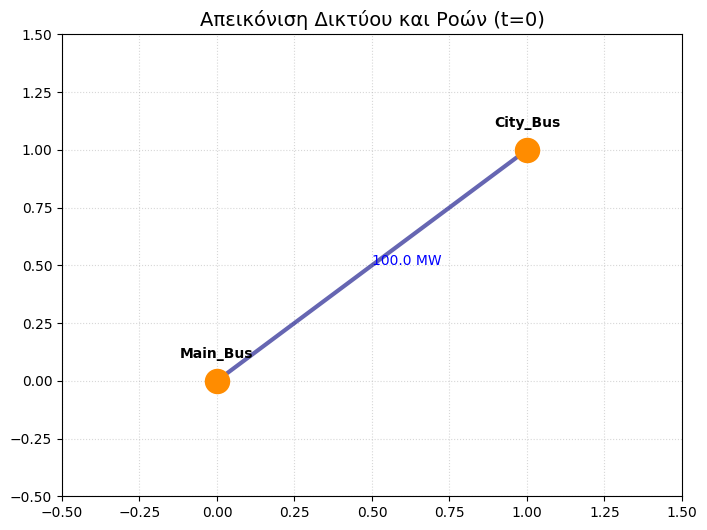

d:\DEV\pypsa-project\.venv\Lib\site-packages\pandas\plotting\_matplotlib\core.py:1831: UserWarning:

Attempting to set identical low and high ylims makes transformation singular; automatically expanding.



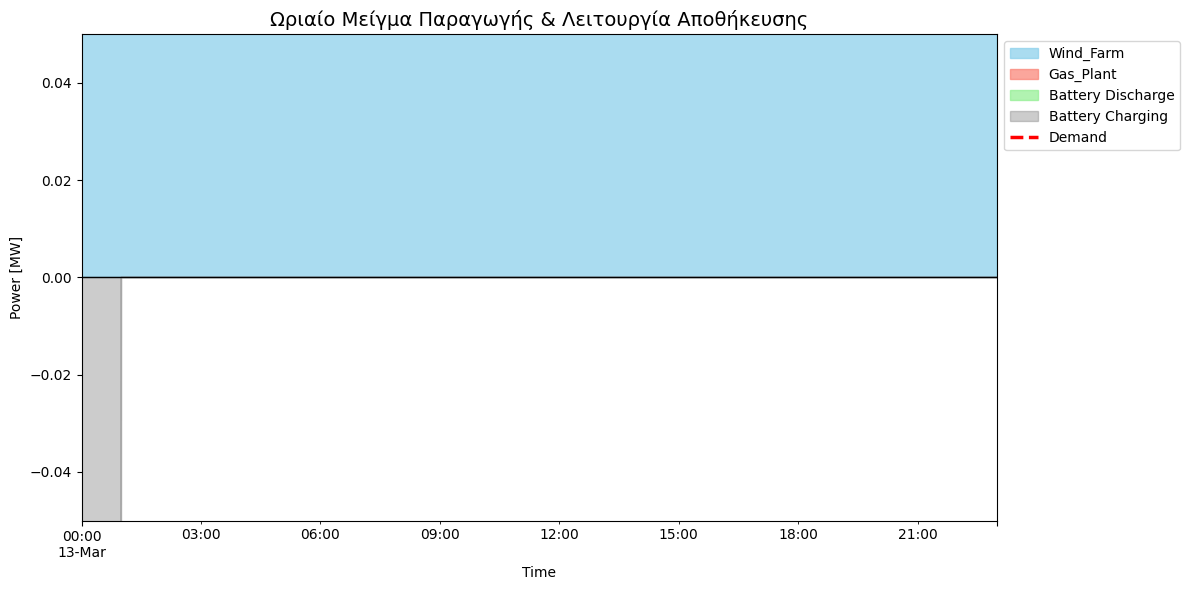


Συνολικό Κόστος Λειτουργίας: 170799.60 €
Συνολική Παραγωγή Αιολικών: 1721.70 MWh


In [ ]:
import matplotlib.pyplot as plt
import pypsa
import numpy as np
import pandas as pd

# 1. Ορισμός Χρονικού Πλαισίου (24 ώρες)
snapshots = pd.date_range("2026-03-13 00:00", "2026-03-13 23:00", freq="h")
network = pypsa.Network()
network.set_snapshots(snapshots)

# 2. Προσθήκη Κόμβων με συντεταγμένες
network.add("Bus", "Main_Bus", x=0, y=0)
network.add("Bus", "City_Bus", x=1, y=1)

# 3. Προσθήκη Γραμμής Μεταφοράς
network.add("Line", "Main_to_City", 
            bus0="Main_Bus", 
            bus1="City_Bus", 
            s_nom=300, # <--------------------
            x=0.1, r=0.01)

# 4. Προσθήκη Μεταβαλλόμενης Ζήτησης (Load)
load_profile = [100, 90, 80, 85, 90, 110, 150, 200, 220, 230, 240, 250, 
                240, 230, 220, 210, 230, 280, 300, 290, 250, 200, 150, 120]
network.add("Load", "City_Load", bus="City_Bus", p_set=load_profile)

# 5. Προσθήκη Αιολικού Πάρκου (Wind Power)
wind_availability = pd.Series(np.random.uniform(0.2, 0.8, len(snapshots)), index=snapshots)
network.add("Generator", "Wind_Farm", 
            bus="Main_Bus", 
            p_nom=150,  # <--------------------
            p_max_pu=wind_availability, 
            marginal_cost=0)

# 6. Προσθήκη Μονάδας Φυσικού Αερίου (Backup)
network.add("Generator", "Gas_Plant", 
            bus="Main_Bus", 
            p_nom=1000, 
            marginal_cost=60)

# 7. Προσθήκη Μπαταρίας
network.add("StorageUnit", "Big_Battery", 
            bus="Main_Bus", 
            p_nom=100, 
            max_hours=4, 
            efficiency_store=0.9, 
            efficiency_dispatch=0.9)

# 8. Επίλυση (Optimization)
network.optimize(solver_name='highs')


# 1. Δες τις γωνίες φάσης (σε ακτίνια) για κάθε ώρα
print("Γωνίες Φάσης (θ):")
print(network.buses_t.v_ang)

# 2. Δες τις τιμές ενέργειας ανά κόμβο (Shadow Prices / LMPs)
# Αυτό μας δείχνει αν υπάρχει συμφόρηση στο δίκτυο
print("\nΤιμές ανά Κόμβο (€/MWh):")
print(network.buses_t.marginal_price)

# 3. Δες αν οι γραμμές έφτασαν στο όριο (Loading)
loading = (network.lines_t.p0.abs() / network.lines.s_nom) * 100
print("\nΦόρτιση Γραμμών (%):")
print(loading)






# --- ΓΡΑΦΗΜΑ 1: ΧΕΙΡΟΚΙΝΗΤΗ ΣΧΕΔΙΑΣΗ ΔΙΚΤΥΟΥ ---
# (Αποφεύγουμε το σφάλμα StringDtype της network.plot())

fig, ax = plt.subplots(figsize=(8, 6))

# Σχεδίαση Κόμβων
ax.scatter(network.buses.x, network.buses.y, s=300, color='darkorange', zorder=5)
for i, txt in enumerate(network.buses.index):
    ax.annotate(txt, (network.buses.x.iloc[i], network.buses.y.iloc[i] + 0.1), 
                ha='center', fontweight='bold', fontsize=10)

# Σχεδίαση Γραμμών
for name, line in network.lines.iterrows():
    bus0 = network.buses.loc[line.bus0]
    bus1 = network.buses.loc[line.bus1]
    flow = network.lines_t.p0.iloc[0].loc[name] # Ροή την 1η ώρα
    ax.plot([bus0.x, bus1.x], [bus0.y, bus1.y], color='navy', linewidth=3, alpha=0.6)
    ax.text((bus0.x+bus1.x)/2, (bus0.y+bus1.y)/2, f"{flow:.1f} MW", color='blue')

ax.set_xlim(-0.5, 1.5)
ax.set_ylim(-0.5, 1.5)
ax.set_title("Απεικόνιση Δικτύου και Ροών (t=0)", fontsize=14)
ax.grid(True, linestyle=':', alpha=0.5)
plt.show()

# --- ΓΡΑΦΗΜΑ 2: ΜΙΓΜΑ ΠΑΡΑΓΩΓΗΣ & ΜΠΑΤΑΡΙΑ ---
# Διαχωρισμός μπαταρίας για να επιτραπεί το stacked=True

df_plot = network.generators_t.p.copy()
df_plot["Battery Discharge"] = network.storage_units_t.p.clip(lower=0)
df_plot["Battery Charge"] = network.storage_units_t.p.clip(upper=0)

fig, ax = plt.subplots(figsize=(12, 6))

# Σχεδίαση Θετικής Παραγωγής (Stacked Area)
df_plot.drop("Battery Charge", axis=1).plot(
    kind="area", ax=ax, stacked=True, alpha=0.7, color=['skyblue', 'salmon', 'lightgreen']
)

# Σχεδίαση Φόρτισης Μπαταρίας (Κάτω από το μηδέν)
df_plot["Battery Charge"].plot(kind="area", ax=ax, color="grey", alpha=0.4, label="Battery Charging")

# Σχεδίαση Ζήτησης (Γραμμή)
network.loads_t.p_set.sum(axis=1).plot(ax=ax, color="red", linewidth=2.5, label="Demand", linestyle="--")

plt.axhline(y=0, color='black', linewidth=1)
plt.title("Ωριαίο Μείγμα Παραγωγής & Λειτουργία Αποθήκευσης", fontsize=14)
plt.ylabel("Power [MW]")
plt.xlabel("Time")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

# --- ΕΚΤΥΠΩΣΗ ΣΤΑΤΙΣΤΙΚΩΝ ---
print(f"\nΣυνολικό Κόστος Λειτουργίας: {network.objective:.2f} €")
print(f"Συνολική Παραγωγή Αιολικών: {network.generators_t.p['Wind_Farm'].sum():.2f} MWh")